# Stochastic Processes Final Project

**Instructor: Dr. Peyvandi**

Student Name:

Student ID:



# Applications of Gaussian Processes
First you will be introduced to Gaussian Processes. You will bridge continuous-time stochastic processes and discrete computational inference. You will build a Gaussian Process (GP) regression framework from scratch, sample hyperparameter distributions using Markov Chain Monte Carlo (MCMC), and implement a score-driven diffusion process using Langevin dynamics.

**Project Overview & Objectives**

1. Construct Gaussian Process (GP) prior spaces from foundational mathematical kernels.

2. Derive and implement the analytical updates for Gaussian Process Regression under noisy observations.

3. Transition to sampling-based inference by building a Metropolis-Hastings MCMC sampler to optimize function space hyperparameters over a log-marginal likelihood surface.

4. Simulate a continuous-time Itô diffusion via the Euler-Maruyama discretization scheme using the Unadjusted Langevin Algorithm (ULA).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Gaussian Process

Recall that a random vector $X \sim \mathcal{N}(\mu, \Sigma)$ has a multivariate normal distribution defined by its mean vector $\mu$ and covariance matrix $\Sigma$. Its probability density function is:$$f(x) = \frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}} \exp\left(-\frac{1}{2}(x-\mu)^\top \Sigma^{-1} (x-\mu)\right)$$

A stochastic process $\{X(t) \mid t \in T\}$ is a Gaussian Process (GP) if and only if every finite dimensional projection (i.e., every finite subset $\{X(t_1), \dots, X(t_n)\}$) is jointly Gaussian. A GP is completely specified by its mean function $m(t) = \mathbb{E}[X(t)]$ and its covariance function (kernel) $k(s, t) = \mathbb{E}[(X(s) - m(s))(X(t) - m(t))]$.

The choice of the kernel function encodes structural assumptions about the underlying stochastic process:
- **Radial Basis Function (RBF) Kernel:** Defines a stationary process where covariance depends only on the distance between inputs. It is infinitely mean-square differentiable, forcing the generated sample paths to be incredibly smooth.
$$k_{RBF}(x, x') = \sigma^2 \exp\left(-\frac{\|x - x'\|^2}{2\ell^2}\right)$$

- **Brownian Motion (Wiener Process) Kernel:** Defines a non-stationary process indexable for $t \geq 0$ with independent increments where $W(0) = 0$. Its sample paths are continuous everywhere but differentiable nowhere.
$$k_{BM}(s, t) = \min(s, t)$$

Task 1: Implement both the RBF and Brownian motion kernels, construct their respective covariance matrices, and draw random sample paths from each GP prior.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def rbf_kernel(x1, x2, sigma=1.0, length_scale=1.0):
    """
    Computes the RBF (squared-exponential) kernel matrix between two vectors.
    """
    x1 = np.atleast_2d(x1).T
    x2 = np.atleast_2d(x2).T

    # TODO: Calculate the pairwise squared Euclidean distance matrix between x1 and x2
    sqdist = None

    # TODO: Return the scaled exponential covariance matrix
    return None

def brownian_kernel(x1, x2):
    """
    Computes the covariance matrix for a standard Brownian motion k(s, t) = min(s, t).
    Assumes inputs are non-negative.
    """
    x1 = np.atleast_2d(x1).T
    x2 = np.atleast_2d(x2).T

    # TODO: Calculate min(s, t) for all pairs using numpy vectorization
    return None

# --- Domain Setups ---
x_rbf = np.linspace(-5, 5, 200)
x_brownian = np.linspace(0, 10, 500) # Standard Brownian motion starts at t=0

# --- Covariance Matrix Generation ---
# TODO: Compute the RBF and Brownian kernel matrices over their respective domains
K_rbf = None
K_brownian = None

# Add a tiny noise term to the diagonals for numerical stability (jitter)
K_rbf += 1e-8 * np.eye(len(x_rbf))
K_brownian += 1e-8 * np.eye(len(x_brownian))

# --- Prior Sampling ---
# TODO: Draw 5 sample paths from each GP prior using `np.random.multivariate_normal`
samples_gaussian = None
samples_brownian = None

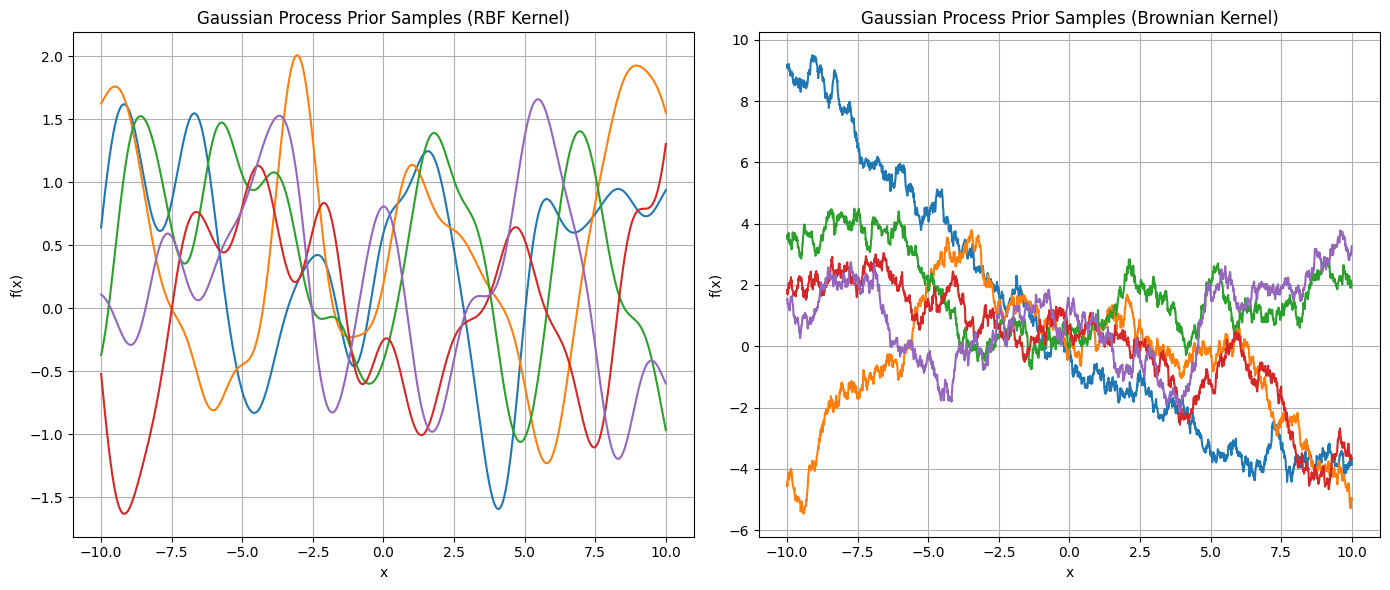

In [9]:
# --- Visualizing the Sample Paths ---
plt.figure(figsize=(14, 6))

# Plot RBF Samples
plt.subplot(1, 2, 1)
for s in samples_gaussian:
    plt.plot(x_rbf, s)
plt.title("GP Prior Samples (Smooth RBF Kernel)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)

# Plot Brownian Motion Samples
plt.subplot(1, 2, 2)
for s in samples_brownian:
    plt.plot(x_brownian, s)
plt.title("GP Prior Samples (Rough Brownian Kernel)")
plt.xlabel("t")
plt.ylabel("W(t)")
plt.grid(True)

plt.tight_layout()
plt.show()

## GP Regression

Assume we observe a training dataset $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n$ governed by an underlying latent target function $f(x)$ corrupted by independent and identically distributed (i.i.d.) Gaussian measurement noise $\epsilon_i$:
$$y_i = f(x_i) + \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, \sigma_y^2)$$

By placing a non-parametric prior distribution over the target function space, $f \sim \mathcal{GP}(0, k)$, the joint distribution of our observed training outputs $y \in \mathbb{R}^n$ and the unobserved latent target evaluations $f_* \in \mathbb{R}^{m}$ at test locations $X_*$ can be structurally arranged as a partitioned multivariate normal distribution:

$$\begin{bmatrix} y \\ f_* \end{bmatrix} \sim \mathcal{N} \left( 0, \begin{bmatrix} K(X,X) + \sigma_y^2 I_n & K(X,X_*) \\ K(X_*,X) & K(X_*,X_*) \end{bmatrix} \right)$$

Applying the Linear Gaussian Conditioning Theorem, the conditional distribution $f_* \mid X, y, X_*$ preserves its Gaussian identity, yielding the posterior predictive distribution $\mathcal{N}(\mu_*, \Sigma_*)$, defined by:
$$\mu_* = K(X_*, X) \left[ K(X,X) + \sigma_y^2 I_n \right]^{-1} y$$$$\Sigma_* = K(X_*, X_*) - K(X_*, X) \left[ K(X,X) + \sigma_y^2 I_n \right]^{-1} K(X, X_*)$$

Task 2: Compute the predictive conditional operators to translate a prior functional space into a data-constrained posterior representation.

In [ ]:
# --- Data Generation ---
def true_function(x):
    return np.sin(x)

x = np.linspace(-5, 5, 200)
x_train = np.array([-4, -3, -2, -1, 0, 1, 2, 3, 4])
noise_var = 0.2**2
y_train = true_function(x_train) + np.sqrt(noise_var)*np.random.randn(len(x_train))

# --- Posterior Computation ---
# TODO: Compute the required covariance matrices: K_xx, K_xs, K_ss
# Ensure you add the noise variance to the diagonal of K_xx!
K_xx = None
K_xs = None
K_ss = None

# TODO: Compute the inverse of K_xx
# Hint: For better numerical stability in production code, we typically use Cholesky
# decomposition, but np.linalg.inv is acceptable for this assignment.
K_inv = None

# TODO: Compute the posterior mean and covariance
mu_post = None
cov_post = None

# Sample from the posterior
posterior_samples = np.random.multivariate_normal(
    mu_post,
    cov_post + 1e-8*np.eye(len(x)),
    size=5
)

# Plotting the Posterior
plt.figure(figsize=(10,5))
plt.scatter(x_train, y_train, color="black", zorder=5, label="Observations")
plt.plot(x, mu_post, linewidth=3, label="Posterior Mean")

std = np.sqrt(np.diag(cov_post))
plt.fill_between(x, mu_post - 2*std, mu_post + 2*std, alpha=0.2, label="95% Confidence Interval")

for s in posterior_samples:
    plt.plot(x, s, alpha=0.5)

plt.title("GP Posterior Predictive Distribution")
plt.legend()
plt.grid(True)
plt.show()

## MCMC: Bayesian Inference Over Hyperparameters

In practical settings, fixing hyperparameters like the kernel length scale $\ell$ can lead to severe underfitting or overfitting. A fully Bayesian approach treats these parameters as random variables rather than static design choices.
We define the hyperparameter posterior distribution over the length scale $\ell$ given our data via Bayes' Theorem:
$$\pi(\ell) = p(\ell \mid X, y) = \frac{p(y \mid X, \ell) p(\ell)}{p(y \mid X)} \propto p(y \mid X, \ell) p(\ell)$$
, Where:
- $p(\ell)$ is the prior distribution over the hyperparameter, encoding our engineering assumptions (e.g., ensuring $\ell > 0$).
- $p(y \mid X, \ell)$ is the marginal likelihood (the evidence), which integrates out the latent function values $f$.

For Gaussian Processes, the log marginal likelihood is analytically tractable and can be expressed as:
$$\log p(y \mid X, \ell) = \underbrace{-\frac{1}{2} y^\top K_{\ell}^{-1} y}_{\text{Data Fit Term}} - \underbrace{\frac{1}{2} \log |K_{\ell}|}_{\text{Complexity Penalty}} - \underbrace{\frac{n}{2} \log(2\pi)}_{\text{Normalization Constant}}$$

The Occam's Razor Penalty: Notice the tension between the first two terms. As the length scale $\ell$ shrinks, the kernel becomes highly flexible, optimizing the Data Fit Term but causing the determinant $|K_{\ell}|$ to explode, which heavily penalizes the model via the Complexity Penalty.

**The Metropolis-Hastings Algorithm**:

 Because the normalizing constant $p(y \mid X) = \int p(y \mid X, \ell)p(\ell)d\ell$ is analytically intractable, we cannot sample from $\pi(\ell)$ directly. Instead, we construct an ergodic Markov chain $\{\ell_0, \ell_1, \dots, \ell_N\}$ whose stationary distribution is exactly $\pi(\ell)$.

 Given a state $\ell^{(t)}$, we sample a candidate state $\ell^*$ from a symmetric proposal distribution $q(\ell^* \mid \ell^{(t)}) \sim \mathcal{N}(\ell^{(t)}, \tau^2)$. The candidate is accepted with probability:$$\alpha(\ell^{(t)}, \ell^*) = \min\left(1, \frac{\pi(\ell^*)}{\pi(\ell^{(t)})}\right)$$To ensure numerical stability and prevent arithmetic underflow, we evaluate this condition entirely in log-space:$$\log \alpha = \log \pi(\ell^*) - \log \pi(\ell^{(t)})$$If a random draw from $\log U \sim \log(\text{Uniform}(0,1))$ is less than $\log \alpha$, the transition is validated and $\ell^{(t+1)} = \ell^*$; otherwise, the chain stays at its current state $\ell^{(t+1)} = \ell^{(t)}$.

 A detailed description of this method can be found in Section 2 of Foreman-Mackey et al. (2013), which is accessible [here](https://arxiv.org/abs/1202.3665).

 Task 3: Implement a Gamma prior distribution for $\ell$, complete the full log-posterior evaluation matrix expression, and construct the Metropolis-Hastings loop.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def log_prior_lengthscale(l):
    """
    Evaluates the log-prior probability density.
    We assume l follows a Gamma distribution: l ~ Gamma(shape=2.0, scale=1.0)
    Density: p(l) \propto l^(shape-1) * exp(-l/scale) for l > 0
    """
    # TODO: Enforce the support boundary condition for the length scale parameter
    # Return -np.inf for non-positive values. Otherwise, return the log-density.
    pass

def log_posterior_lengthscale(l, x_train, y_train, sigma=1.0, noise_std=0.2):
    """
    Computes the unnormalized log posterior: log pi(l) = log p(y | X, l) + log p(l)
    """
    # 1. Evaluate the prior first
    log_prior = log_prior_lengthscale(l)
    if np.isinf(log_prior):
        return -np.inf

    # TODO: Construct the noisy covariance matrix K_ell using rbf_kernel
    K = None

    try:
        # TODO: Compute the log-determinant safely using np.linalg.slogdet
        # and the matrix inverse using np.linalg.inv
        sign, logdet = None, None
        K_inv = None

        n = len(y_train)

        # TODO: Calculate the full log marginal likelihood component
        log_likelihood = None

        # TODO: Return the unnormalized log posterior
        return None

    except np.linalg.LinAlgError:
        # Handle non-positive definite matrix instances gracefully
        return -np.inf

def metropolis_hastings(n_samples, initial_l, proposal_width=0.15):
    """
    Runs a Metropolis-Hastings sampler to generate draws from the lengthscale posterior.
    """
    samples = []
    current = initial_l
    current_logp = log_posterior_lengthscale(current, x_train, y_train)

    for i in range(n_samples):
        # TODO: Generate a candidate state using a symmetric Gaussian proposal
        proposal = None

        # TODO: Evaluate the log posterior of the proposed state
        proposal_logp = None

        # TODO: Calculate the Metropolis-Hastings acceptance probability in log-space
        log_alpha = None

        # TODO: Perform the Metropolis acceptance step
        # Target update variables: `current` and `current_logp`

        samples.append(current)

    return np.array(samples)

# Execution block (Assuming x_train and y_train are derived from Part 2)
chain = metropolis_hastings(n_samples=15000, initial_l=0.5, proposal_width=0.15)

# Diagnostic Visualizations
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(chain, color='teal', lw=0.5)
plt.axhline(1.0, color='red', linestyle='--', label='True Kernel Setup Value')
plt.title("Metropolis-Hastings Parameter Trace")
plt.xlabel("MCMC Iteration")
plt.ylabel(r"Length scale ($\ell$)")
plt.legend()

plt.subplot(1, 2, 2)
# Apply a 20% burn-in filter to eliminate initialization bias
burn_in = int(0.2 * len(chain))
plt.hist(chain[burn_in:], bins=50, density=True, color='darkblue', alpha=0.7)
plt.title(r"Empirical Posterior Density $\pi(\ell \mid X, y)$")
plt.xlabel(r"Length scale ($\ell$)")
plt.tight_layout()
plt.show()

## Langevin Dynamics

Instead of updating discrete Markov chains based on algebraic acceptance criteria, we can formalize our sampling trajectories as a continuous-time path governed by a Stochastic Differential Equation (SDE). Consider the continuous-time Itô diffusion:
$$dX_t = \frac{1}{2} \nabla \log \pi(X_t) dt + dW_t$$
, where:
- $W_t$ represents a standard multi-dimensional Brownian motion process.
- $\nabla \log \pi(X_t)$ is the score function of our target distribution.

By the Fokker-Planck equation, the **stationary distribution** of this process is exactly $\pi(x)$. To simulate this continuous-time process on a computer, we use the Euler-Maruyama discretization:
$$X_{k+1} = X_k + \frac{\epsilon}{2} \nabla \log \pi(X_k) + \sqrt{\epsilon} Z_k$$
, where $\epsilon > 0$ defines the finite simulation time step size, and $Z_k \sim \mathcal{N}(0, I)$ provides the independent stochastic noise vector driving the random-walk diffusion.

Task 4: Implement the Euler-Maruyama update step to sample from a bi-modal Gaussian mixture using Unadjusted Langevin Algorithm (ULA).

In [ ]:
# Target Distribution: A mixture of two Gaussians
def log_pi(x):
    # Unnormalized log density
    return np.log(0.5*np.exp(-0.5*(x+2)**2) + 0.5*np.exp(-0.5*(x-2)**2))

def score(x):
    # Numerical approximation of the derivative of the log density
    eps = 1e-5
    return (log_pi(x + eps) - log_pi(x - eps)) / (2 * eps)

def langevin_dynamics(n_steps=20000, eps=0.02, x0=0.0):
    x = x0
    samples = []

    for _ in range(n_steps):
        # TODO: Compute the drift term
        drift = None

        # TODO: Compute the stochastic diffusion (noise) term
        noise = None

        # TODO: Execute the Euler-Maruyama update step
        x = None

        samples.append(x)

    return np.array(samples)

samples = langevin_dynamics(n_steps=20000, eps=0.02, x0=0.0)

# Plot Trajectory
plt.figure(figsize=(12,4))
plt.plot(samples[:500], lw=1)
plt.title("Langevin Dynamics Trajectory (Early Segment)")
plt.xlabel("Step")
plt.ylabel("X_t")
plt.grid(True)
plt.show()

# Verify Stationary Distribution
grid = np.linspace(-6,6,300)
true_density = np.exp([log_pi(x) for x in grid])
true_density /= np.trapz(true_density, grid) # Normalize

plt.figure(figsize=(8,4))
plt.hist(samples[5000:], bins=60, density=True, alpha=0.5, label="Langevin Samples (Post Burn-in)")
plt.plot(grid, true_density, lw=2, label="True Target Density")
plt.title("Empirical vs True Distribution")
plt.legend()
plt.grid(True)
plt.show()